In [147]:
# Imports

from datasets import load_from_disk
import numpy as np
from transformers import (
	AutoModelForMaskedLM,
	AutoModelForSequenceClassification,
	AutoTokenizer,
	Trainer,
	TrainingArguments,
    DataCollatorForLanguageModeling
)
from sklearn.metrics import (
	accuracy_score, 
    precision_recall_fscore_support, 
    confusion_matrix, 
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

In [148]:
# constants

large_dataset_path = "data/my_saved_dataset_large"
base_model_path = "data/my_saved_model"
unlabaled_trained_model_path = "data/unlabeled_trained_model"
text_column = "text"

In [149]:
# parameters

seed = 42
num_samples_large_dataset = 5000

large_dataset_epoch = 1
large_dataset_per_device_train_batch_size = 16
large_dataset_logging_steps = 50


stratify_test_size = 0.5

small_dataset_eval_steps = 50
small_dataset_num_train_epochs = 1
small_dataset_per_device_train_batch_size = 8

In [150]:
# Load and prepare dataset for unsupervised training

print("Loading large dataset...")
large_dataset = load_from_disk(large_dataset_path)
large_dataset = large_dataset.shuffle(seed=seed)
if num_samples_large_dataset is not None:
    large_dataset = large_dataset.select(range(num_samples_large_dataset))

Loading large dataset...


In [151]:
# Load tokenizer and model for unsupervised training

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(base_model_path)

print("Loading base model...")
model = AutoModelForMaskedLM.from_pretrained(base_model_path).to("xpu")

Loading tokenizer...
Loading base model...


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 4884.10it/s]
[transformers] This checkpoint seem corrupted. The tied weights mapping for this model specifies to tie cls.predictions.bias to cls.predictions.decoder.bias, but both are absent from the checkpoint, and we could not find another related tied weight for those keys
[transformers] BertForMaskedLM LOAD REPORT from: data/my_saved_model
Key                                        | Status     | 
-------------------------------------------+------------+-
bert.pooler.dense.weight                   | UNEXPECTED | 
classifier.bias                            | UNEXPECTED | 
bert.pooler.dense.bias                     | UNEXPECTED | 
classifier.weight                          | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | MISSING    | 
cls.predictions.transform.dense.weight     | MISSING    | 
cls.predictions.bias                       | MISSING    | 
cls.predictions.transform.dense.bias       | MISSING    | 
cls.pred

In [152]:
# Tokenize the text column of the dataset
def tokenize_batch_large_dataset(batch):
	return tokenizer(
		batch[text_column]	
		, truncation=True,
		max_length=64,
	)

print("Tokenizing text column...")
tokenized_dataset = large_dataset.map(tokenize_batch_large_dataset, batched=True, remove_columns=large_dataset.column_names)


Tokenizing text column...


Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map: 100%|██████████| 5000/5000 [00:03<00:00, 1296.46 examples/s]


In [153]:
# Prepare data collator for masked language modeling

data_collator = DataCollatorForLanguageModeling( tokenizer=tokenizer )

In [154]:
# Set up Trainer for unsupervised training

training_args = TrainingArguments(
	num_train_epochs=large_dataset_epoch,
	logging_steps=large_dataset_logging_steps if large_dataset_logging_steps is not None else 500,
    per_device_train_batch_size=large_dataset_per_device_train_batch_size,
	remove_unused_columns=True
)

trainer = Trainer(
	model=model,
	args=training_args,
	train_dataset=tokenized_dataset,
	data_collator=data_collator
)

In [155]:
# Train the model on the unlabeled text data

print("Starting training on unlabeled text...")
trainer.train()
print("Finished unsupervised training.")
unlabaled_trained_model = model.to("xpu")
unlabaled_trained_model.save_pretrained(unlabaled_trained_model_path)


Starting training on unlabeled text...


Step,Training Loss
50,7.732216
100,6.299083
150,5.714468
200,5.498843
250,5.250921
300,5.250810


Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.08s/it]


Finished unsupervised training.


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.70it/s]


In [156]:
# Load and prepare small dataset for supervised training and testing

small_dataset_path = "data/my_saved_dataset_small"
print("Loading small dataset...")
small_dataset = load_from_disk(small_dataset_path)
combo_column = "combo"
small_dataset = small_dataset.map(
	lambda example: {
		combo_column: f"{example['politics'][0]}{example['sentiment'][0]}".upper()
	},
    remove_columns=["politics", "sentiment"]
)
small_dataset = small_dataset.class_encode_column(combo_column)
print(small_dataset.features)

Loading small dataset...
{'text': Value('string'), 'combo': ClassLabel(names=['LN', 'LP', 'RN', 'RP'])}


In [157]:
# Split the small dataset into training and testing sets, stratifying by the combo column to maintain class distribution

split_dataset = small_dataset.train_test_split(
	test_size=stratify_test_size,
	seed=seed,
	stratify_by_column=combo_column
)
train_dataset = split_dataset["train"]
test_dataset = split_dataset["test"]
print(f"Train size: {len(train_dataset)} | Test size: {len(test_dataset)}")

Train size: 1692 | Test size: 1692


In [158]:
# Tokenize thee text column of the training and testing datasets

def tokenize_with_labels(batch):
    tokens = tokenizer(
        batch["text"],
        truncation=True,
        max_length=64,
        padding="max_length",
    )
    tokens["labels"] = batch[combo_column]
    return tokens

train_tokens = train_dataset.map(
	tokenize_with_labels,
	batched=True,
	remove_columns=train_dataset.column_names
)
test_tokens = test_dataset.map(
    tokenize_with_labels,
    batched=True,
    remove_columns=test_dataset.column_names
)

In [159]:
# Make the model for supervised training

label2id = {
    "LP": 0,
    "LN": 1,
    "RP": 2,
    "RN": 3
}

clf_model = AutoModelForSequenceClassification.from_pretrained(
    unlabaled_trained_model_path,
    label2id=label2id,
    id2label={value: key for key, value in label2id.items()},
    ignore_mismatched_sizes=True,
)

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 10407.44it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: data/unlabeled_trained_model
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from 

In [160]:
# Make the trainer for supervised training, with custom evaluation metrics

cls_args = TrainingArguments(
    eval_strategy="steps",
    eval_steps=small_dataset_eval_steps,
	num_train_epochs=small_dataset_num_train_epochs,
    per_device_train_batch_size=small_dataset_per_device_train_batch_size
)

# source for base code is https://medium.com/@rakeshrajpurohit/customized-evaluation-metrics-with-hugging-face-trainer-3ff00d936f99
def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted"
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

pred_trainer = Trainer(
	model=clf_model,
	args=cls_args,
	train_dataset=train_tokens,
	eval_dataset=test_tokens,
    compute_metrics=compute_metrics
)

In [161]:
# Train the model on the labeled data and evaluate

print("Starting training with metrics...")
pred_trainer.train()

Starting training with metrics...


Step,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
50,No log,0.524424,0.763593,0.787151,0.763593,0.758413
100,No log,0.377704,0.847518,0.857706,0.847518,0.847612
150,No log,0.297925,0.897163,0.898418,0.897163,0.897123
200,No log,0.232613,0.921395,0.922305,0.921395,0.921371
212,No log,0.229848,0.921986,0.923062,0.921986,0.921975


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.09it/s]


TrainOutput(global_step=212, training_loss=0.49348330947588076, metrics={'train_runtime': 100.7323, 'train_samples_per_second': 16.797, 'train_steps_per_second': 2.105, 'total_flos': 55648987490304.0, 'train_loss': 0.49348330947588076, 'epoch': 1.0})

Calculating confusion matrix...


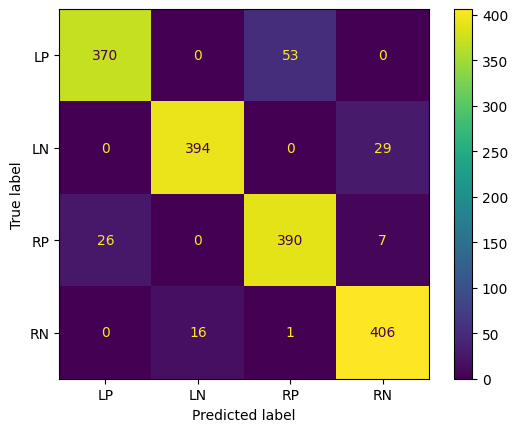

In [162]:
# Calculate and display the confusion matrix for the test set predictions

print("Calculating confusion matrix...")
pred_output = pred_trainer.predict(test_tokens)
predictions = np.argmax(pred_output.predictions, axis=-1)
true_labels = np.array(test_tokens["labels"])
cm = confusion_matrix(true_labels, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['LP', 'LN', 'RP', 'RN'])
disp.plot()
plt.show()

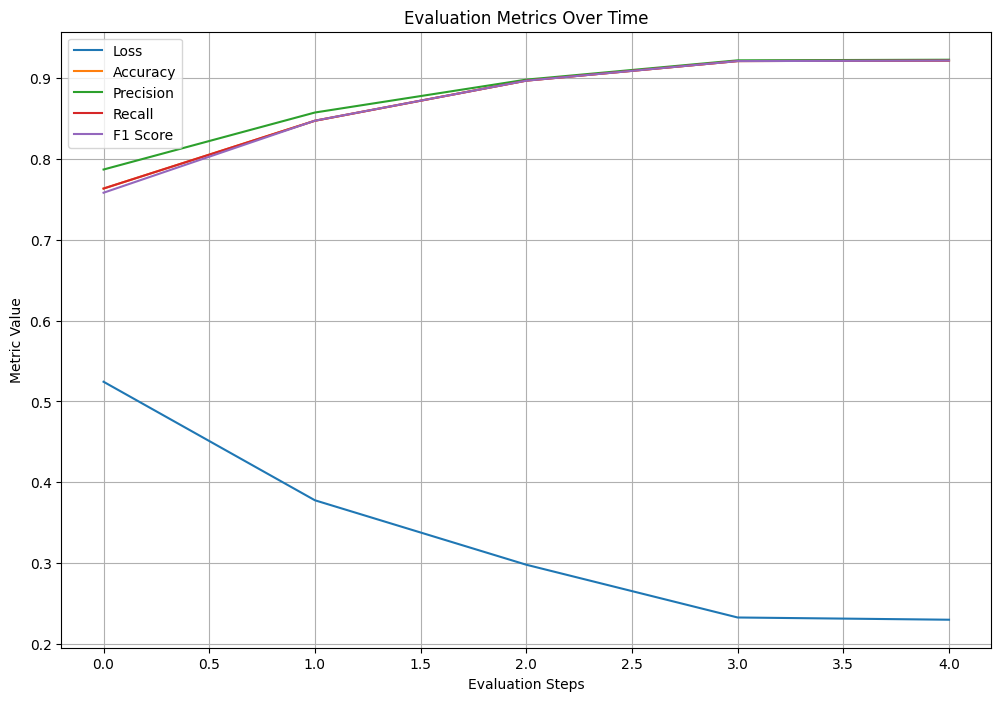

In [163]:
# Display metrics

loss = []
accuracy = []
precision = []
recall = []
f1 = []

for record in pred_trainer.state.log_history:
    # train_ruuntime is only present in the final record, when the measured metrics are no longer there
    if 'train_runtime' in record:
        break
    loss.append(record["eval_loss"])
    accuracy.append(record["eval_accuracy"])
    precision.append(record["eval_precision"])
    recall.append(record["eval_recall"])
    f1.append(record["eval_f1"])

plt.figure(figsize=(12, 8))
plt.plot(loss, label="Loss")
plt.plot(accuracy, label="Accuracy")
plt.plot(precision, label="Precision")
plt.plot(recall, label="Recall")
plt.plot(f1, label="F1 Score")
plt.xlabel("Evaluation Steps")
plt.ylabel("Metric Value")
plt.title("Evaluation Metrics Over Time")
plt.legend()
plt.grid()
plt.show()
    